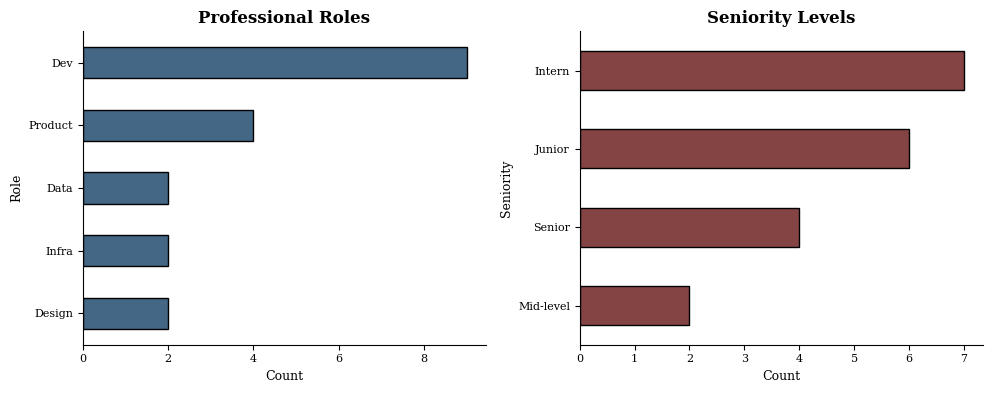

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação dos dados
data = {
    'Role': ['Infra', 'Design', 'Product', 'Infra', 'Product', 'Dev', 'Dev', 'Dev', 
             'Data', 'Product', 'Dev', 'Dev', 'Design', 'Dev', 'Product', 'Dev', 
             'Dev', 'Dev', 'Data'],
    'Seniority': ['Junior', 'Junior', 'Senior', 'Intern', 'Junior', 'Intern', 'Senior', 
                  'Mid-level', 'Mid-level', 'Intern', 'Intern', 'Intern', 'Junior', 
                  'Senior', 'Junior', 'Intern', 'Senior', 'Intern', 'Junior']
}

df = pd.DataFrame(data)

# 2. Contagem por categoria
role_counts = df['Role'].value_counts().sort_values()
seniority_counts = df['Seniority'].value_counts().sort_values()

# 3. Configuração do gráfico (Estilo Científico)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.4)

# Gráfico de Funções (Roles)
role_counts.plot(kind='barh', ax=ax1, color='#446785', edgecolor='black')
ax1.set_title('Professional Roles', fontsize=12, fontweight='bold')
ax1.set_xlabel('Count')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Gráfico de Senioridade (Seniority)
seniority_counts.plot(kind='barh', ax=ax2, color='#854444', edgecolor='black')
ax2.set_title('Seniority Levels', fontsize=12, fontweight='bold')
ax2.set_xlabel('Count')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 4. Ajuste final e salvamento
plt.tight_layout()
plt.savefig('participants_demographics.png', dpi=300, bbox_inches='tight')
plt.show()

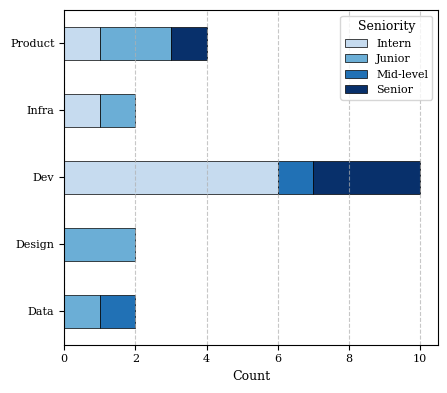

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Data preparation (extracted from the image)
data = [
    ["Infra", "1A6M", "Junior", 8, "Homem"],
    ["Design", "3A", "Junior", 10, "Homem"],
    ["Product", "3A", "Senior", -1, "Mulher"],
    ["Infra", "3M", "Intern", 6, "Homem"],
    ["Product", "3A", "Junior", 12, "Mulher"],
    ["Dev", "1A3M", "Intern", -1, "Mulher"],
    ["Dev", "2A10M", "Mid-level", -1, "Homem"],
    ["Dev", "6A", "Senior", -1, "Homem"],
    ["Data", "2A", "Mid-level", -1, "Homem"],
    ["Product", "2A3M", "Intern", 10, "Homem"],
    ["Dev", "3A", "Intern", 11, "Homem"],
    ["Dev", "1A5M", "Intern", 8, "Homem"],
    ["Dev", "2A6M", "Intern", 7, "Mulher"],
    ["Design", "2A6M", "Junior", 8, "Mulher"],
    ["Dev", "1A3M", "Senior", -1, "Homem"],
    ["Product", "1A8M", "Junior", -1, "Homem"],
    ["Dev", "2A1M", "Intern", 11, "Mulher"],
    ["Dev", "2A10M", "Senior", -1, "Homem"],
    ["Dev", "2A5M", "Intern", -1, "Homem"],
    ["Data", "1A7M", "Junior", 8, "Homem"]
]

df = pd.DataFrame(data, columns=["Team", "LabTime", "Seniority", "Semester", "Gender"])

# Helper to convert LabTime (e.g., 1A6M) to months
def convert_to_months(s):
    months = 0
    if 'A' in s:
        parts = s.split('A')
        months += int(parts[0]) * 12
        s = parts[1]
    if 'M' in s:
        months += int(s.replace('M', ''))
    return months

df['Months'] = df['LabTime'].apply(convert_to_months)
df['Semester_Clean'] = df['Semester'].replace(-1, np.nan)

# ICSE-style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8
})

# Figure size matches the original subplot width (10 / 2.2)
fig, ax = plt.subplots(1, 1, figsize=(4.55, 4))

# Plot 1: Team composition by seniority (stacked bar)
ct = pd.crosstab(df['Team'], df['Seniority'])
seniority_order = ['Intern', 'Junior', 'Mid-level', 'Senior']
ct = ct.reindex(columns=[s for s in seniority_order if s in ct.columns])
ct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#c6dbef', '#6baed6', '#2171b5', '#08306b'],
    edgecolor='black',
    linewidth=0.5
 )
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig('team_distribution.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

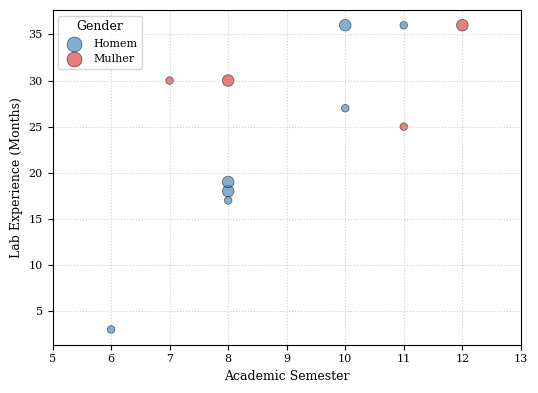

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Data preparation (extracted from the image)
data = [
    ["Infra", "1A6M", "Junior", 8, "Homem"],
    ["Design", "3A", "Junior", 10, "Homem"],
    ["Product", "3A", "Senior", -1, "Mulher"],
    ["Infra", "3M", "Intern", 6, "Homem"],
    ["Product", "3A", "Junior", 12, "Mulher"],
    ["Dev", "1A3M", "Intern", -1, "Mulher"],
    ["Dev", "6A", "Senior", -1, "Homem"],
    ["Dev", "2A10M", "Mid-level", -1, "Homem"],
    ["Data", "2A", "Mid-level", -1, "Homem"],
    ["Product", "2A3M", "Intern", 10, "Homem"],
    ["Dev", "3A", "Intern", 11, "Homem"],
    ["Dev", "1A5M", "Intern", 8, "Homem"],
    ["Dev", "2A6M", "Intern", 7, "Mulher"],
    ["Design", "2A6M", "Junior", 8, "Mulher"],
    ["Dev", "1A3M", "Senior", -1, "Homem"],
    ["Product", "1A8M", "Junior", -1, "Homem"],
    ["Dev", "2A1M", "Intern", 11, "Mulher"],
    ["Dev", "2A10M", "Senior", -1, "Homem"],
    ["Dev", "2A5M", "Intern", -1, "Homem"],
    ["Data", "1A7M", "Junior", 8, "Homem"]
]

df = pd.DataFrame(data, columns=["Team", "LabTime", "Seniority", "Semester", "Gender"])

# Helper to convert LabTime (e.g., 1A6M) to months
def convert_to_months(s):
    months = 0
    if 'A' in s:
        parts = s.split('A')
        months += int(parts[0]) * 12
        s = parts[1]
    if 'M' in s:
        months += int(s.replace('M', ''))
    return months

df['Months'] = df['LabTime'].apply(convert_to_months)
df['Semester_Clean'] = df['Semester'].replace(-1, np.nan)

# ICSE-style settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8
})

# Figure size matches the original subplot width (10 * 1.2 / 2.2)
fig, ax = plt.subplots(1, 1, figsize=(5.45, 4))

# Plot 2: Lab time vs semester (scatter)
gender_colors = {'Homem': '#2b7bba', 'Mulher': '#d62728'}
size_map = {'Intern': 30, 'Junior': 70, 'Mid-level': 120, 'Senior': 200}

for gender in df['Gender'].unique():
    subset = df[df['Gender'] == gender]
    ax.scatter(
        subset['Semester_Clean'],
        subset['Months'],
        s=subset['Seniority'].map(size_map),
        c=gender_colors[gender],
        label=gender,
        alpha=0.6,
        edgecolors='black',
        linewidths=0.5
    )

ax.set_xlabel("Academic Semester")
ax.set_ylabel("Lab Experience (Months)")
ax.legend(title="Gender", loc='upper left')
ax.set_xlim(5, 13)
ax.grid(linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()